## Implementation of the Genetic Algorithm for Missing Value Imputation in RCBD

In this section, we present the practical implementation of the Genetic Algorithm (GA) designed for imputing missing values in Randomized Complete Block Design (RCBD) datasets.  
The following part of the notebook translates the theoretical concepts described in documentation into a implementation, covering all essential components of the algorithm:  

- **Chromosome representation**  
- **Population initialization**  
- **Fitness evaluation**  
- **Selection, crossover, and mutation operators**  

This is followed by testing and experimental evaluation, where the algorithm’s performance is assessed on synthetic RCBD data and the obtained results are analyzed.

In [1]:
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
from copy import deepcopy

In [2]:
def calculate_sse(predicted, true = None, mask=None):
    predicted = predicted.astype(float)

    if true is not None and mask is not None:
      true = true.astype(float)
      error = (predicted - true) ** 2
      masked_error = error * mask
      sse = np.sum(masked_error)
    else:
      # in this case, data isn't artifically generated so we actually don't know the missing value at all and only have predicted matrix
      # model based SSE (RCBD based)

      sample_mean = predicted.mean()
      row_means = predicted.mean(axis=1)
      col_means = predicted.mean(axis=0)

      sse = 0
      for i in range(predicted.shape[0]):
          for j in range(predicted.shape[1]):
              y_ij = predicted[i, j]
              y_hat_ij = row_means[i] + col_means[j] - sample_mean
              sse += (y_ij - y_hat_ij) ** 2
    return sse

In [3]:
class Individual:
    def __init__(self, rcbd : pd.DataFrame, rcbd_true : pd.DataFrame = None):
        self.code = calculate_code(rcbd)
        self.rcbd = rcbd; # original rcbd with missing values
        self.rcbd_true = rcbd_true # optional, we don't have this with real data
        self.second_nan = self.calculate_second_nan()
        self.fitness = self.calc_fitness()

    def calc_fitness(self):
        rcbd_c = self.rcbd.copy()
        decode_value, row1, col1 = self.decode()

        nan_positions = list(zip(*np.where(rcbd_c.isna())))
        # we need to insert the predicted second missing value if original table had 2 nans
        if self.second_nan is not None and len(nan_positions) > 1:
            row2, col2 = nan_positions[1]
            rcbd_c.iloc[row2, col2] = self.second_nan

        t_values = rcbd_c.iloc[row1].dropna().values.astype(float)
        t_scaled = [int(round(v * 10)) for v in t_values]
        min_s = min(t_scaled)
        max_s = max(t_scaled)

        eps_s = max(1, (max_s - min_s) // 10)

        min_value = (min_s - eps_s) / 10.0
        max_value = (max_s + eps_s) / 10.0

        # if chromosome code isn't in allowed range, fitness is set to -inf
        if decode_value < min_value or decode_value > max_value:
            return -float("inf")

        rcbd_c.iloc[row1, col1] = decode_value

        if self.rcbd_true is not None:
          mask = pd.DataFrame(0, index=rcbd_c.index, columns=rcbd_c.columns)
          mask.iloc[row1, col1] = 1
          if self.second_nan is not None and len(nan_positions) > 1:
              mask.iloc[row2, col2] = 1
          return -calculate_sse(rcbd_c.values, self.rcbd_true.values, mask.values)
        else:
          return -calculate_sse(rcbd_c.values)

    def binary_code(self):
      return ''.join(['1' if bit else '0' for bit in self.code])

    def decode(self):
      t_row_ids, t_col_ids = np.where(self.rcbd.isna())
      t_row_id = t_row_ids[0]
      t_col_id = t_col_ids[0]

      t_values = self.rcbd.iloc[t_row_id].dropna().values.astype(float)
      t_scaled = [int(round(v * 10)) for v in t_values]

      min_value = min(t_scaled)
      max_value = max(t_scaled)

      epsilon = max(1, (max_value - min_value) // 10)
      min_value -= epsilon

      decoded_value = (min_value + int(self.binary_code(), 2))
      decoded_value = decoded_value / 10.0

      return decoded_value, t_row_id, t_col_id

    def __str__(self):
        binary = self.binary_code()
        decoded_value, row, col = self.decode()
        return f"Chromosome binary code is {binary} and decoded value is {decoded_value} (at row {row}, column {col})\n"

    def calculate_second_nan(self):
        rcbd_c = self.rcbd.copy()
        nan_positions = list(zip(*np.where(rcbd_c.isna())))
        if len(nan_positions) < 2:
            return None;
        # second_nan calculation based on the equation from the paper
        decoded, first_row, first_col = self.decode()
        rcbd_c.iloc[first_row, first_col] = decoded

        row, col = nan_positions[1]
        
        a = self.rcbd.shape[0]  # number of rows (blocks)
        b = self.rcbd.shape[1]  # number of columns (treatments)
        row_sum = rcbd_c.iloc[row].dropna().sum()
        col_sum = rcbd_c.iloc[:, col].dropna().sum()
        total_sum = rcbd_c.stack().sum()

        second_nan = (a * row_sum + b * col_sum - total_sum) / ((a - 1) * (b - 1))
        return second_nan

In [4]:
def calculate_code(table : pd.DataFrame):
  # each individual should represent the missing value in the RCBD table.
    
  # first we need to determine range for missing value.
  t_row_ids, _ = np.where(table.isna())
  t_row_id = t_row_ids[0]

  t_values = table.iloc[t_row_id].dropna().values.astype(float)
  t_rounded_values = [round(v, 1) for v in t_values]
  t_scaled_values = [int(round(v * 10)) for v in t_rounded_values]

  min_value = min(t_scaled_values)
  max_value = max(t_scaled_values)

  epsilon = max(1, (max_value - min_value) // 10)

  min_value -= epsilon
  max_value += epsilon

  n = max_value - min_value + 1  # number of values in [min - eps, max + eps]
  size = math.ceil(math.log2(n)) # size of the chromosome
  chromosome = [random.random() < 0.7 for _ in range(size)]

  return chromosome

In [5]:
# the method generates an RCBD table by populating it with random values within the [lower, upper] range
# this approach is acceptable in our case, as we are working with synthetic data
# in general, these values would not be random but rather measured values obtained from an actual experiment
def generate_rcbd_table(n_rows = 2, n_cols = 2, lower_bound = 1, upper_bound = 30, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    data = np.round(np.random.uniform(lower_bound, upper_bound, size=(n_rows, n_cols)), 1)

    df = pd.DataFrame(data,
                      index=[f"T{i+1}" for i in range(n_rows)],
                      columns=[f"B{j+1}" for j in range(n_cols)])
    return df

In [6]:
def initial_population(rcbd : pd.DataFrame, rcbd_true: pd.DataFrame = None, size = 10):
    population = []
    seen_codes = set()
    while True:
        if rcbd_true is not None:
          chromosome = Individual(rcbd, rcbd_true)
        else:
          chromosome = Individual(rcbd)
        decode_value, row, _ = chromosome.decode()

        # condition: decoded chromosome in range [min_value-eps, max_value+eps]
        t_values = rcbd.iloc[row].dropna().values.astype(float)
        t_scaled = [int(round(v * 10)) for v in t_values]
        min_s = min(t_scaled)
        max_s = max(t_scaled)
        eps_s = max(1, (max_s - min_s) // 10)

        min_value = (min_s - eps_s) / 10.0
        max_value = (max_s + eps_s) / 10.0

        binary = chromosome.binary_code()

        if decode_value <= max_value and decode_value >= min_value and binary not in seen_codes:
            population.append(chromosome)
            seen_codes.add(binary)

        if len(population) == size:
            break

    return population

In [7]:
# Selecting individuals from the population based on roulette selection
def roulette_selection(population, num_selected=2, epsilon=1e-6):
    assert num_selected <= len(population), "Cannot select more individuals than population size without replacement."

    population = [ind for ind in population if not np.isinf(ind.fitness)]
    fitness_values = np.array([ind.fitness for ind in population])

    min_fit = np.min(fitness_values)
    shifted_fitness = fitness_values - min_fit + epsilon

    total = np.sum(shifted_fitness)
    
    if not np.isfinite(total) or total <= 0:
      probabilities = np.full(len(population), 1.0 / len(population))
    else:
      probabilities = shifted_fitness / total

    selected = []
    while True:
        idx = np.random.choice(len(population), p=probabilities)
        candidate = population[idx]
        if not any(np.array_equal(candidate.code, other.code) for other in selected):
          selected.append(candidate)
        if len(selected) == num_selected:
          break;

    assert len(selected) == len({tuple(ind.code) for ind in selected}), \
     "Cannot select more individuals than population size without replacement."

    return selected

In [8]:
def tournament_selection(population, tournament_size):
    tournament_size = min(len(population), tournament_size)
    participants = random.sample(population, tournament_size)
    return max(participants, key=lambda x: x.fitness)

In [9]:
def crossover(parent1: Individual, parent2: Individual, child1: Individual, child2: Individual, crossover_prob = 0.9):
    # randomly select two breakpoints
    if random.random() < crossover_prob:
      bp1 = random.randrange(1, len(parent1.code)) # first and last position are excluded because we want to take the middle part of the parent
      
      # with few bits, crossover often swaps only one identical bit, producing identical offsprings to parents.
      if len(parent1.code) < 5:
          child1.code[:bp1] = parent1.code[:bp1]
          child1.code[bp1:] = parent2.code[bp1:]

          child2.code[:bp1] = parent2.code[:bp1]
          child2.code[bp1:] = parent1.code[bp1:]
          
      bp2 = bp1
      while bp2 == bp1:
          bp2 = random.randrange(1, len(parent1.code))

      bps = sorted([bp1, bp2])

      child1.code[:bps[0]] = parent1.code[:bps[0]]
      child1.code[bps[0]:bps[1]] = parent2.code[bps[0]:bps[1]]
      child1.code[bps[1]:] = parent1.code[bps[1]:]

      child2.code[:bps[0]] = parent2.code[:bps[0]]
      child2.code[bps[0]:bps[1]] = parent1.code[bps[0]:bps[1]]
      child2.code[bps[1]:] = parent2.code[bps[1]:]

    else:
        child1.code[:] = parent1.code[:]
        child2.code[:] = parent2.code[:]

In [10]:
def mutation(child: Individual, mutation_prob = 0.2, number_of_bp = 2):
  # mutation is performed such as following : randomly select two breaking points and invert all the bits between them
  if random.random() < mutation_prob:
    bp1 = random.randrange(1, len(child.code))
    if number_of_bp == 2:
        bp2 = bp1
        while bp2 == bp1:
          bp2 = random.randrange(1, len(child.code))

        bps = sorted([bp1, bp2])
        for i in range(bps[0], bps[1]):
          child.code[i] = not child.code[i]
    elif number_of_bp == 1:
        for i in range(bp1, len(child.code)):
          child.code[i] = not child.code[i]

In [11]:
def ga(initial_population, num_generations, elitism_size, mutation_prob, crossover_prob, selection_type, mutation_type, tournament_size = None):
    new_population = [Individual(initial_population[0].rcbd, initial_population[0].rcbd_true) for _ in range(len(initial_population))]

    if elitism_size % 2 != len(initial_population) % 2:
        elitism_size += 1

    best_fitnesses = []
    best_decoded_values = []
    mean_mapes = [] # calculating mapes for second missing value by equation from the paper
    population = deepcopy(initial_population)
    prev_population = deepcopy(population)
    epsilon = 1e-6 

    print(f"\n--- Generation {0} ---")
    for ind in population:
      val, r, c = ind.decode()
      print(f"Code: {ind.binary_code()} | Decoded: {val} | Fitness: {ind.fitness}")

    for it in range(num_generations):
        population.sort(key=lambda x: x.fitness, reverse = True)
        best_fitnesses.append(population[0].fitness)
        print("best fitness: ", population[0].fitness)
        best_decoded_value, _, _ = population[0].decode()
        best_decoded_values.append(best_decoded_value)

        second_values = [ind.second_nan for ind in population if ind.second_nan is not None]
        if it > 0 and len(second_values) != 0:
            # equation from the paper
            mape_vals = [
                abs((prev_population[i].second_nan - population[i].second_nan) / (prev_population[i].second_nan + epsilon))
                for i in range(len(population))
                ]
            mean_mape = np.mean(mape_vals)
            mean_mapes.append(mean_mape)

        new_population[:elitism_size] = population[:elitism_size]
        for i in range(elitism_size, len(population), 2):
            if selection_type == "roulette":
                parents = roulette_selection(population)
                crossover(parents[0], parents[1], new_population[i], new_population[i+1], crossover_prob)
            elif selection_type == "tournament":
                parent1 = tournament_selection(population, tournament_size)
                parent2 = tournament_selection(population, tournament_size)
                crossover(parent1, parent2, new_population[i], new_population[i+1], crossover_prob)
                
            mutation(new_population[i], mutation_prob, mutation_type)
            mutation(new_population[i+1], mutation_prob, mutation_type)

            # the fitness value is calculated only during instance initialization, so after crossover or mutation operations, 
            # the fitness will not be automatically updated.
            new_population[i].fitness = new_population[i].calc_fitness()
            new_population[i+1].fitness = new_population[i+1].calc_fitness()

            new_population[i].second_nan = new_population[i].calculate_second_nan()
            new_population[i+1].second_nan = new_population[i+1].calculate_second_nan()
        prev_population = deepcopy(population)
        population = deepcopy(new_population)

        print(f"\n--- Generation {it+1} ---")
        for ind in population:
          val, r, c = ind.decode()
          print(f"Code: {ind.binary_code()} | Decoded: {val} | Fitness: {ind.fitness}")

    return population, best_fitnesses, best_decoded_values, mean_mapes

## Testing and Experimental Evaluation

In this section, we test the implemented Genetic Algorithm on synthetic RCBD datasets and real RCBD datasets.
The objectives of this phase are to:  

- Evaluate its performance under different parameter settings
- Analyze its ability to accurately impute missing values

In addition to numerical metrics, we will visualize the algorithm’s performance over generations using the following plots:  

- **Fitness over generations** – tracking the best fitness value in each generation.  
- **Mean MAPE over generations** – showing the average error of the predicted second missing value.  
- **Difference over generations** – illustrating the deviation between the best decoded value and the true value.

In the **experimental part**, the obtained results will be compared with the results reported in the literature to assess the accuracy and efficiency of the proposed approach.  

## Testing for synthetic data

In [12]:
# original RCBD table (etc. 3 treatments x 3 blocks)
true_table = generate_rcbd_table(3, 3, 1, 20, 42)
display(true_table)
# mask:
mask = pd.DataFrame(0, index=true_table.index, columns=true_table.columns)
# choosing random fields
mask.iloc[0, 1] = 1
mask.iloc[2, 2] = 1

# predicted values that GA would generate
predicted_table = true_table.copy().astype(float)
predicted_table.iloc[0, 1] = 19.5
predicted_table.iloc[2, 2] = 12.5
sse = calculate_sse(predicted_table.values, true_table.values, mask.values)
print(f"SSE: {sse:.4f}")

,B1,B2,B3
T1,8.1,19.1,14.9
T2,12.4,4.0,4.0
T3,2.1,17.5,12.4


SSE: 0.1700


In [13]:
error_table = (predicted_table - true_table)
masked_error_table = error_table * mask

print("Difference (only on positions with errors):")
display(masked_error_table)

Difference (only on positions with errors):


,B1,B2,B3
T1,0.0,0.4,0.0
T2,0.0,0.0,0.0
T3,0.0,0.0,0.1


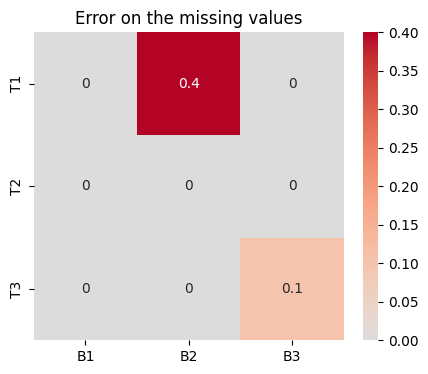

In [14]:
plt.figure(figsize=(5,4))
sns.heatmap(masked_error_table, annot=True, cmap="coolwarm", center=0)
plt.title("Error on the missing values")
plt.show()

In [15]:
# randomly removing one or two values from rcbd table or removing one value from the given position
def hide_random_value(table: pd.DataFrame, num_missing=1, seed=None, fixed_position=None):
    assert num_missing in [1, 2], "Only 1 or 2 missing values supported."
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    table_hidden = table.copy() 

    rows, cols = table.shape
    total_cells = [(i, j) for i in range(rows) for j in range(cols)]

    if fixed_position is not None:
        assert num_missing == 1, "Fixed position mode supports only num_missing=1."
        hidden_positions = [fixed_position]
    else:
        hidden_positions = random.sample(total_cells, num_missing)

    true_values = [table_hidden.iat[i, j] for i, j in hidden_positions]

    for i, j in hidden_positions:
        table_hidden.iat[i, j] = np.nan

    return table_hidden, hidden_positions, true_values

### Testing for one missing value

In [16]:
df = generate_rcbd_table(5, 5, 10, 50, 46)
print("Original table:")
display(df)

df_hidden, pos, original_val = hide_random_value(df, 1, 46)

print("\nTable with hidden value(s):")
display(df_hidden)

original_val_fmt = [round(float(v), 1) for v in original_val]
pos_fmt = [tuple(p) for p in pos]

print(f"\nRemoved value(s): {original_val_fmt} at position(s) {pos_fmt}")

Original table:


,B1,B2,B3,B4,B5
T1,41.4,35.4,20.0,40.3,22.5
T2,47.5,11.7,27.6,46.5,28.2
T3,30.3,13.4,27.1,39.8,44.7
T4,22.9,14.2,42.1,25.8,35.1
T5,11.4,22.0,11.9,24.9,20.5



Table with hidden value(s):


,B1,B2,B3,B4,B5
T1,41.4,35.4,NaN,40.3,22.5
T2,47.5,11.7,27.6,46.5,28.2
T3,30.3,13.4,27.1,39.8,44.7
T4,22.9,14.2,42.1,25.8,35.1
T5,11.4,22.0,11.9,24.9,20.5



Removed value(s): [20.0] at position(s) [(0, 2)]


In [17]:
chromosome = Individual(df_hidden, df)

In [18]:
print("Random generated chromosome: ", chromosome.binary_code())

Random generated chromosome:  11011101


In [19]:
decoded_val, row, col = chromosome.decode()
print(f"Decoded value: {decoded_val} and row: {row}, col: {col} where missing value is.")

Decoded value: 42.8 and row: 0, col: 2 where missing value is.


In [20]:
print("Fitness of this random generated chromosome is: ", chromosome.fitness)

Fitness of this random generated chromosome is:  -519.8399999999999


In [25]:
population = initial_population(df_hidden, df)

In [26]:
population_original = population

In [27]:
for individual in population:
    print(individual)

Chromosome binary code is 00011101 and decoded value is 23.6 (at row 0, column 2)

Chromosome binary code is 01110011 and decoded value is 32.2 (at row 0, column 2)

Chromosome binary code is 11011111 and decoded value is 43.0 (at row 0, column 2)

Chromosome binary code is 01010111 and decoded value is 29.4 (at row 0, column 2)

Chromosome binary code is 10110110 and decoded value is 38.9 (at row 0, column 2)

Chromosome binary code is 00111010 and decoded value is 26.5 (at row 0, column 2)

Chromosome binary code is 01111111 and decoded value is 33.4 (at row 0, column 2)

Chromosome binary code is 10111001 and decoded value is 39.2 (at row 0, column 2)

Chromosome binary code is 11011110 and decoded value is 42.9 (at row 0, column 2)

Chromosome binary code is 01000011 and decoded value is 27.4 (at row 0, column 2)



In [28]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population, 20, 2, 0.2, 0.9, "roulette", 2)


--- Generation 0 ---
Code: 00011101 | Decoded: 23.6 | Fitness: -12.96000000000001
Code: 01110011 | Decoded: 32.2 | Fitness: -148.84000000000006
Code: 11011111 | Decoded: 43.0 | Fitness: -529.0
Code: 01010111 | Decoded: 29.4 | Fitness: -88.35999999999997
Code: 10110110 | Decoded: 38.9 | Fitness: -357.2099999999999
Code: 00111010 | Decoded: 26.5 | Fitness: -42.25
Code: 01111111 | Decoded: 33.4 | Fitness: -179.55999999999997
Code: 10111001 | Decoded: 39.2 | Fitness: -368.6400000000001
Code: 11011110 | Decoded: 42.9 | Fitness: -524.41
Code: 01000011 | Decoded: 27.4 | Fitness: -54.75999999999998
best fitness:  -12.96000000000001

--- Generation 1 ---
Code: 00011101 | Decoded: 23.6 | Fitness: -12.96000000000001
Code: 00111010 | Decoded: 26.5 | Fitness: -42.25
Code: 01010111 | Decoded: 29.4 | Fitness: -88.35999999999997
Code: 01111111 | Decoded: 33.4 | Fitness: -179.55999999999997
Code: 00110010 | Decoded: 25.7 | Fitness: -32.489999999999995
Code: 01111011 | Decoded: 33.0 | Fitness: -169.0
C

In [29]:
def plot_fitness_over_generations(best_fitnesses):
    generations = list(range(1, len(best_fitnesses) + 1))

    plt.figure(figsize=(7, 5))
    plt.plot(generations, best_fitnesses, color='orange', linestyle='-', label='Best fitness')
    plt.xlabel('Generation')
    plt.ylabel('Fitness')
    plt.title('Fitness over Generations')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [30]:
def plot_mean_mape_over_generations(mean_mapes):
    plt.figure(figsize=(8, 5))
    plt.plot(mean_mapes, label="Mean MAPE of 2nd missing value")
    plt.xlabel("Generation")
    plt.ylabel("Mean MAPE")
    plt.title("MAPE over Generations")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
def plot_difference_over_generations(best_decoded_values, true_value): # plotting the difference between decoded value and true value over generations
    generations = list(range(1, len(best_fitnesses) + 1))

    plt.figure(figsize=(7, 5))
    plt.plot(generations, np.array(best_decoded_values) - true_value, color='blue', label='Best decoded value')
    plt.xlabel('Generation')
    plt.ylabel('Decoded value - true value')
    plt.title('Difference over Generations')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

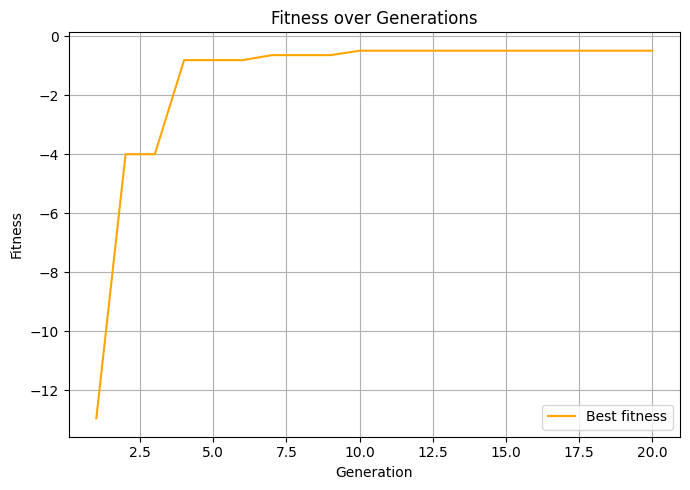

In [32]:
plot_fitness_over_generations(best_fitnesses)

In [33]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
true_value = df.iloc[row, col]
print(f'True value that was hidden in the RCBD table: {true_value}')
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')

True value that was hidden in the RCBD table: 20.0
Predicted value for null in RCBD table with GA is: 20.7


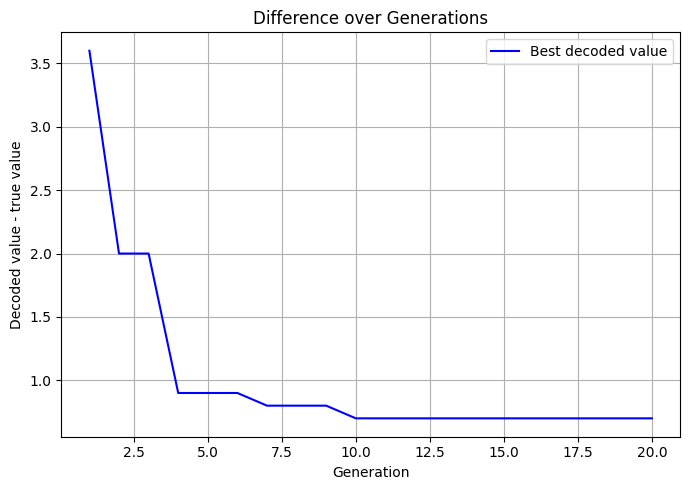

In [34]:
plot_difference_over_generations(best_decoded_values, true_value)

In [35]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population_original, 20, 2, 0.2, 0.9, "tournament", 1, 5)


--- Generation 0 ---
Code: 00011101 | Decoded: 23.6 | Fitness: -12.96000000000001
Code: 01110011 | Decoded: 32.2 | Fitness: -148.84000000000006
Code: 11011111 | Decoded: 43.0 | Fitness: -529.0
Code: 01010111 | Decoded: 29.4 | Fitness: -88.35999999999997
Code: 10110110 | Decoded: 38.9 | Fitness: -357.2099999999999
Code: 00111010 | Decoded: 26.5 | Fitness: -42.25
Code: 01111111 | Decoded: 33.4 | Fitness: -179.55999999999997
Code: 10111001 | Decoded: 39.2 | Fitness: -368.6400000000001
Code: 11011110 | Decoded: 42.9 | Fitness: -524.41
Code: 01000011 | Decoded: 27.4 | Fitness: -54.75999999999998
best fitness:  -12.96000000000001

--- Generation 1 ---
Code: 00011101 | Decoded: 23.6 | Fitness: -12.96000000000001
Code: 00111010 | Decoded: 26.5 | Fitness: -42.25
Code: 00111010 | Decoded: 26.5 | Fitness: -42.25
Code: 00111010 | Decoded: 26.5 | Fitness: -42.25
Code: 00011101 | Decoded: 23.6 | Fitness: -12.96000000000001
Code: 00011101 | Decoded: 23.6 | Fitness: -12.96000000000001
Code: 00011010 

In [36]:
population = initial_population(df_hidden, df)

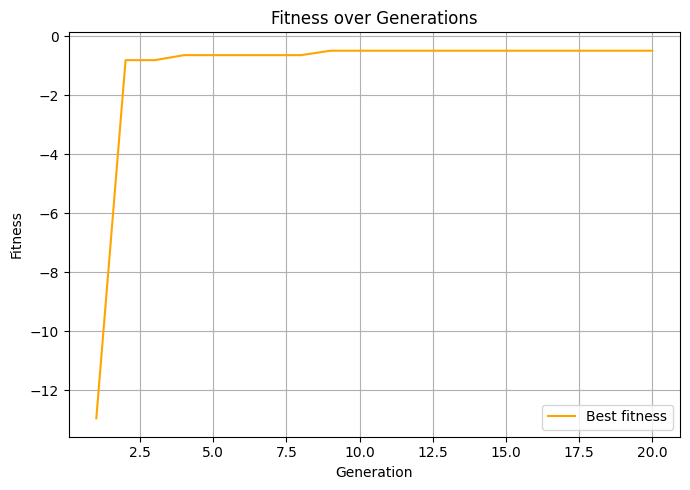

In [37]:
plot_fitness_over_generations(best_fitnesses)

In [38]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
true_value = df.iloc[row, col]
print(f'True value that was hidden in the RCBD table: {true_value}')
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')

True value that was hidden in the RCBD table: 20.0
Predicted value for null in RCBD table with GA is: 24.6


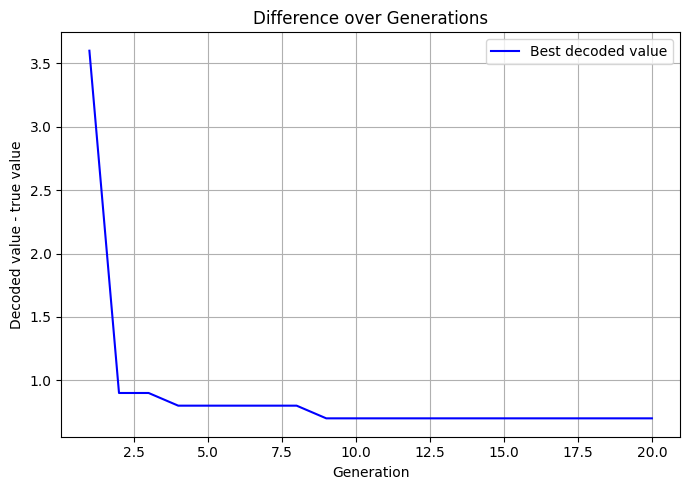

In [39]:
plot_difference_over_generations(best_decoded_values, true_value)

## Testing for two missing values

In [40]:
df = generate_rcbd_table(5, 5, 10, 50, 46)
print("Original table:")
display(df)

df_hidden, pos, original_val = hide_random_value(df, 2, 46)

print("\nTable with hidden value(s):")
display(df_hidden)

original_val_fmt = [round(float(v), 1) for v in original_val]
pos_fmt = [tuple(p) for p in pos]

print(f"\nRemoved value(s): {original_val_fmt} at position(s) {pos_fmt}")

Original table:


,B1,B2,B3,B4,B5
T1,41.4,35.4,20.0,40.3,22.5
T2,47.5,11.7,27.6,46.5,28.2
T3,30.3,13.4,27.1,39.8,44.7
T4,22.9,14.2,42.1,25.8,35.1
T5,11.4,22.0,11.9,24.9,20.5



Table with hidden value(s):


,B1,B2,B3,B4,B5
T1,41.4,35.4,NaN,40.3,22.5
T2,47.5,11.7,27.6,46.5,28.2
T3,30.3,13.4,NaN,39.8,44.7
T4,22.9,14.2,42.1,25.8,35.1
T5,11.4,22.0,11.9,24.9,20.5



Removed value(s): [20.0, 27.1] at position(s) [(0, 2), (2, 2)]


In [41]:
chromosome = Individual(df_hidden, df)

In [42]:
print("Random generated chromosome: ", chromosome.binary_code())

Random generated chromosome:  11011101


In [43]:
decoded_val, row, col = chromosome.decode()
print(f"Decoded value: {decoded_val} and row: {row}, col: {col} where missing value is.")
print(f'Predicted value for second missing value in RCBD table is: {chromosome.second_nan}')

Decoded value: 42.8 and row: 0, col: 2 where missing value is.
Predicted value for second missing value in RCBD table is: 35.00625000000001


In [44]:
print("Fitness of this random generated chromosome is: ", chromosome.fitness)

Fitness of this random generated chromosome is:  -582.3487890625


In [54]:
population = initial_population(df_hidden, df)

In [55]:
population_original = population

In [56]:
for individual in population:
    print(individual)

Chromosome binary code is 11011110 and decoded value is 42.9 (at row 0, column 2)

Chromosome binary code is 11011111 and decoded value is 43.0 (at row 0, column 2)

Chromosome binary code is 10100111 and decoded value is 37.4 (at row 0, column 2)

Chromosome binary code is 01111111 and decoded value is 33.4 (at row 0, column 2)

Chromosome binary code is 00011111 and decoded value is 23.8 (at row 0, column 2)

Chromosome binary code is 10011101 and decoded value is 36.4 (at row 0, column 2)

Chromosome binary code is 00111111 and decoded value is 27.0 (at row 0, column 2)

Chromosome binary code is 10010110 and decoded value is 35.7 (at row 0, column 2)

Chromosome binary code is 00111011 and decoded value is 26.6 (at row 0, column 2)

Chromosome binary code is 10101110 and decoded value is 38.1 (at row 0, column 2)



In [57]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population, 20, 2, 0.2, 0.9, "roulette", 2)


--- Generation 0 ---
Code: 11011110 | Decoded: 42.9 | Fitness: -587.3147265624999
Code: 11011111 | Decoded: 43.0 | Fitness: -592.3019140625
Code: 10100111 | Decoded: 37.4 | Fitness: -345.7444140624999
Code: 01111111 | Decoded: 33.4 | Fitness: -210.43191406249997
Code: 00011111 | Decoded: 23.8 | Fitness: -24.401914062500005
Code: 10011101 | Decoded: 36.4 | Fitness: -308.72878906249997
Code: 00111111 | Decoded: 27.0 | Fitness: -64.65191406250003
Code: 10010110 | Decoded: 35.7 | Fitness: -284.0822265625001
Code: 00111011 | Decoded: 26.6 | Fitness: -58.430664062499986
Code: 10101110 | Decoded: 38.1 | Fitness: -372.9197265625
best fitness:  -24.401914062500005

--- Generation 1 ---
Code: 00011111 | Decoded: 23.8 | Fitness: -24.401914062500005
Code: 00111011 | Decoded: 26.6 | Fitness: -58.430664062499986
Code: 10011111 | Decoded: 36.6 | Fitness: -304.2494140625
Code: 01111101 | Decoded: 33.2 | Fitness: -250.4747265625
Code: 00111111 | Decoded: 27.0 | Fitness: -96.00816406249994
Code: 100110

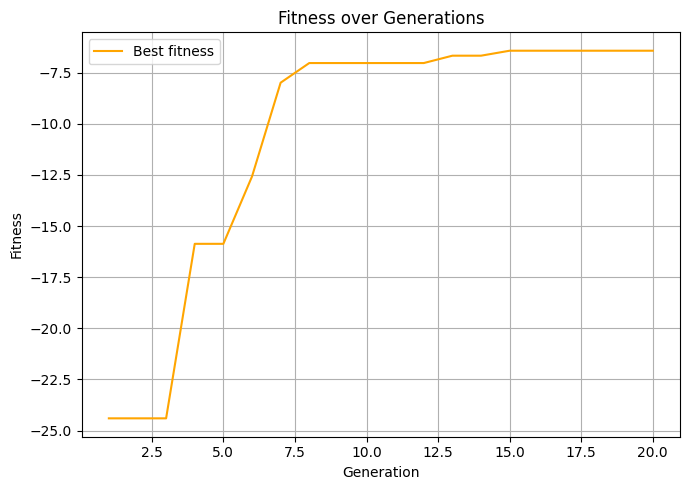

In [58]:
plot_fitness_over_generations(best_fitnesses)

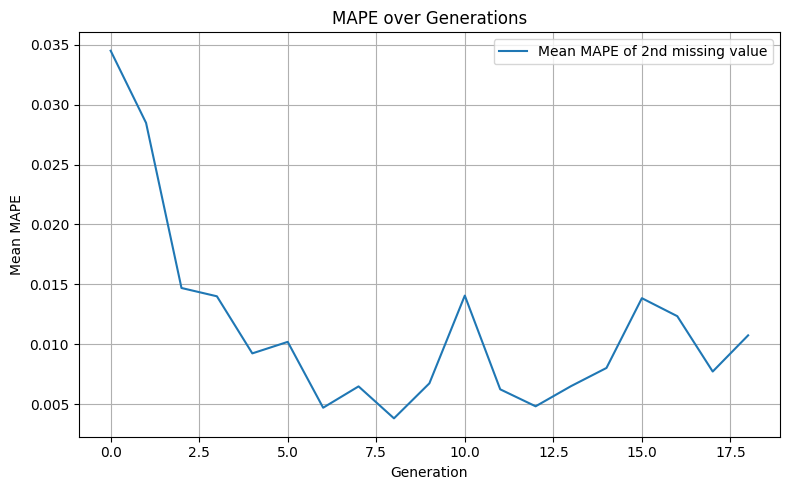

In [59]:
plot_mean_mape_over_generations(mean_maps)

In [60]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
true_value = df.iloc[row, col]
print(f'First true value that was hidden in the RCBD table: {true_value}')
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')
print(f'Second true value that was hidden in the RCBD table: {original_val_fmt[1]}')
print(f'Predicted value for second missing value in RCBD table is: {best_predicted_nan_value.second_nan}')

First true value that was hidden in the RCBD table: 20.0
Predicted value for null in RCBD table with GA is: 20.8
Second true value that was hidden in the RCBD table: 27.1
Predicted value for second missing value in RCBD table is: 29.50625


In [61]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population_original, 20, 2, 0.2, 0.9, "tournament", 1, 5)


--- Generation 0 ---
Code: 11011110 | Decoded: 42.9 | Fitness: -587.3147265624999
Code: 11011111 | Decoded: 43.0 | Fitness: -592.3019140625
Code: 10100111 | Decoded: 37.4 | Fitness: -345.7444140624999
Code: 01111111 | Decoded: 33.4 | Fitness: -210.43191406249997
Code: 00011111 | Decoded: 23.8 | Fitness: -24.401914062500005
Code: 10011101 | Decoded: 36.4 | Fitness: -308.72878906249997
Code: 00111111 | Decoded: 27.0 | Fitness: -64.65191406250003
Code: 10010110 | Decoded: 35.7 | Fitness: -284.0822265625001
Code: 00111011 | Decoded: 26.6 | Fitness: -58.430664062499986
Code: 10101110 | Decoded: 38.1 | Fitness: -372.9197265625
best fitness:  -24.401914062500005

--- Generation 1 ---
Code: 00011111 | Decoded: 23.8 | Fitness: -24.401914062500005
Code: 00111011 | Decoded: 26.6 | Fitness: -58.430664062499986
Code: 00011110 | Decoded: 23.7 | Fitness: -76.59472656249997
Code: 00011111 | Decoded: 23.8 | Fitness: -54.84191406249995
Code: 00111111 | Decoded: 27.0 | Fitness: -111.90472656249997
Code:

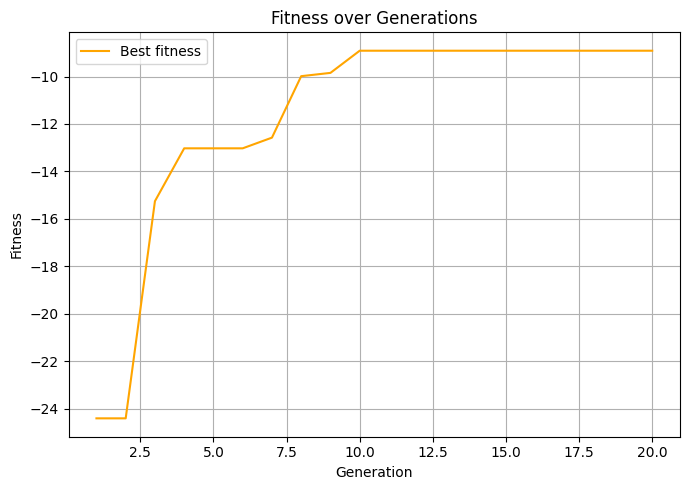

In [62]:
plot_fitness_over_generations(best_fitnesses)

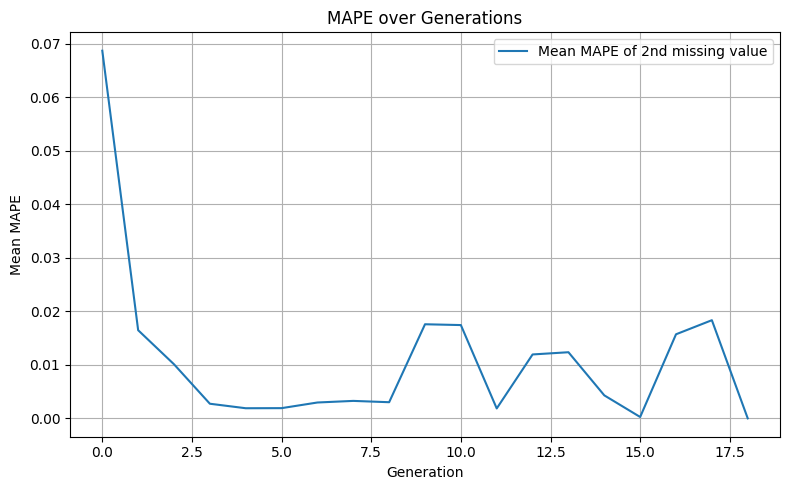

In [63]:
plot_mean_mape_over_generations(mean_maps)

In [64]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
true_value = df.iloc[row, col]
print(f'First true value that was hidden in the RCBD table: {true_value}')
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')
print(f'Second true value that was hidden in the RCBD table: {original_val_fmt[1]}')
print(f'Predicted value for second missing value in RCBD table is: {best_predicted_nan_value.second_nan}')

First true value that was hidden in the RCBD table: 20.0
Predicted value for null in RCBD table with GA is: 21.5
Second true value that was hidden in the RCBD table: 27.1
Predicted value for second missing value in RCBD table is: 29.681250000000006


## Testing with "real" data (case when we truly don't know the missing value)

### Testing for one missing value

In [66]:
data = [
    ((1, 1), 7), ((1, 2), 7), ((1, 3), 15), ((1, 4), 11), ((1, 5), 9),
    ((2, 1), 12), ((2, 2), 17), ((2, 3), 12), ((2, 4), 18), ((2, 5), 18),
    ((3, 1), 14), ((3, 2), 18), ((3, 3), 18), ((3, 4), 19), ((3, 5), 19),
    ((4, 1), 19), ((4, 2), 25), ((4, 3), 22), ((4, 4), 19), ((4, 5), 23),
    ((5, 1), 7),  ((5, 2), 10), ((5, 3), 11), ((5, 4), 15), ((5, 5), 11),
]

rcbd_df = pd.DataFrame([[None]*5 for _ in range(5)])

for (i, j), value in data:
    rcbd_df.iat[i-1, j-1] = value

display(rcbd_df)


df_hidden, pos, _ = hide_random_value(rcbd_df, 1, 46)

print("\nTable with hidden value(s):")
display(df_hidden)

,0,1,2,3,4
0,7,7,15,11,9
1,12,17,12,18,18
2,14,18,18,19,19
3,19,25,22,19,23
4,7,10,11,15,11



Table with hidden value(s):


,0,1,2,3,4
0,7,7,NaN,11,9
1,12,17,12,18,18
2,14,18,18,19,19
3,19,25,22,19,23
4,7,10,11,15,11


In [76]:
population = initial_population(df_hidden)

In [77]:
population_original = population

In [78]:
for individual in population:
    print(individual)

Chromosome binary code is 011111 and decoded value is 9.7 (at row 0, column 2)

Chromosome binary code is 011011 and decoded value is 9.3 (at row 0, column 2)

Chromosome binary code is 110000 and decoded value is 11.4 (at row 0, column 2)

Chromosome binary code is 010011 and decoded value is 8.5 (at row 0, column 2)

Chromosome binary code is 010110 and decoded value is 8.8 (at row 0, column 2)

Chromosome binary code is 001110 and decoded value is 8.0 (at row 0, column 2)

Chromosome binary code is 101101 and decoded value is 11.1 (at row 0, column 2)

Chromosome binary code is 011101 and decoded value is 9.5 (at row 0, column 2)

Chromosome binary code is 001111 and decoded value is 8.1 (at row 0, column 2)

Chromosome binary code is 101011 and decoded value is 10.9 (at row 0, column 2)



In [79]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population, 20, 2, 0.2, 0.9, "roulette", 2)


--- Generation 0 ---
Code: 011111 | Decoded: 9.7 | Fitness: -61.43360000000003
Code: 011011 | Decoded: 9.3 | Fitness: -60.537600000000026
Code: 110000 | Decoded: 11.4 | Fitness: -67.52640000000002
Code: 010011 | Decoded: 8.5 | Fitness: -59.36000000000003
Code: 010110 | Decoded: 8.8 | Fitness: -59.705600000000025
Code: 001110 | Decoded: 8.0 | Fitness: -59.04000000000003
Code: 101101 | Decoded: 11.1 | Fitness: -66.18240000000004
Code: 011101 | Decoded: 9.5 | Fitness: -60.96000000000002
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 101011 | Decoded: 10.9 | Fitness: -65.3504
best fitness:  -59.04000000000003

--- Generation 1 ---
Code: 001110 | Decoded: 8.0 | Fitness: -59.04000000000003
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 011011 | Decoded: 9.3 | Fitness: -60.537600000000026
Code: 011101 | Decoded: 9.5 | Fitness: -60.96000000000002
Code: 011111 | Decoded: 9.7 | Fitness: -61.43360000000003
Code: 001101 | Decoded: 7.9 | Fitness: -59.0144000000000

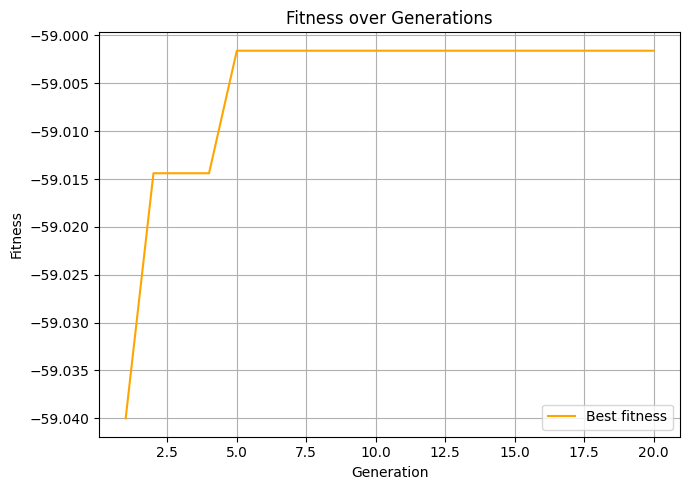

In [80]:
plot_fitness_over_generations(best_fitnesses)

In [81]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')

Predicted value for null in RCBD table with GA is: 7.7


In [82]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population_original, 20, 2, 0.2, 0.9, "tournament", 1, 5)


--- Generation 0 ---
Code: 011111 | Decoded: 9.7 | Fitness: -61.43360000000003
Code: 011011 | Decoded: 9.3 | Fitness: -60.537600000000026
Code: 110000 | Decoded: 11.4 | Fitness: -67.52640000000002
Code: 010011 | Decoded: 8.5 | Fitness: -59.36000000000003
Code: 010110 | Decoded: 8.8 | Fitness: -59.705600000000025
Code: 001110 | Decoded: 8.0 | Fitness: -59.04000000000003
Code: 101101 | Decoded: 11.1 | Fitness: -66.18240000000004
Code: 011101 | Decoded: 9.5 | Fitness: -60.96000000000002
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 101011 | Decoded: 10.9 | Fitness: -65.3504
best fitness:  -59.04000000000003

--- Generation 1 ---
Code: 001110 | Decoded: 8.0 | Fitness: -59.04000000000003
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002
Code: 001111 | Decoded: 8.1 | Fitness: -59.07840000000002

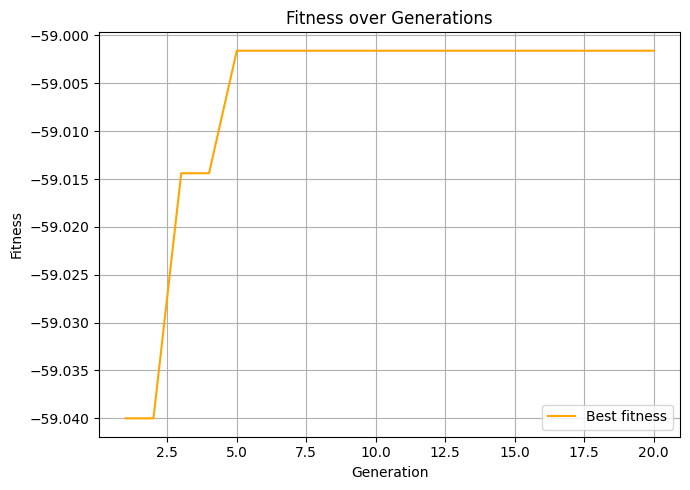

In [83]:
plot_fitness_over_generations(best_fitnesses)

In [84]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')

Predicted value for null in RCBD table with GA is: 7.7


In [85]:
def show_population(population, fitness_values):
    df = pd.DataFrame({
        'Chromosome': [f'Chromosome {i+1}' for i in range(len(population))],
        'Fitness': fitness_values
    })

    labels = [str(i+1) for i in range(len(population))]

    fig, (ax_table, ax_pie) = plt.subplots(1, 2, figsize=(10, 5))

    ax_table.axis('off')
    table_data = df.values.tolist()
    table = ax_table.table(cellText=table_data, colLabels=df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    
    cmap = plt.get_cmap("Set3")
    colors = cmap(np.linspace(0, 1, len(fitness_values)))

    ax_pie.pie(fitness_values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax_pie.axis('equal')
    ax_pie.set_title('Roulette Wheel Selection')

    plt.tight_layout()
    plt.show()

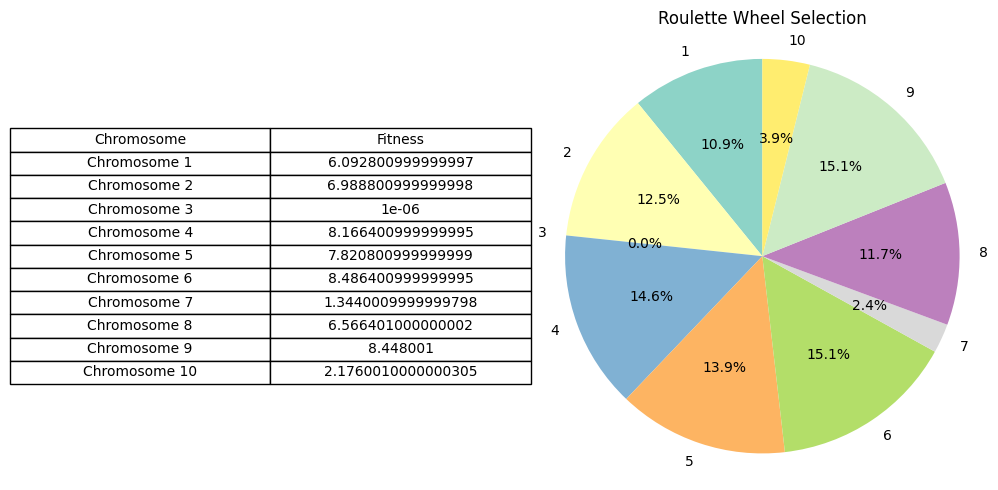

In [89]:
fitness_values = []
for ind in population_original:
    fitness_values.append(ind.fitness)
min_val = min(fitness_values)
if min_val < 0:
    fitness_values = [f - min_val + 1e-6 for f in fitness_values]
    
show_population(population_original, fitness_values)

## Comparing our results with results reported in the literature

In [90]:
# table from the paper (they used this data for their experiments)
data = [
    ((1, 1), 7), ((1, 2), 7), ((1, 3), 15), ((1, 4), 11), ((1, 5), 9),
    ((2, 1), 12), ((2, 2), 17), ((2, 3), 12), ((2, 4), 18), ((2, 5), 18),
    ((3, 1), 14), ((3, 2), 18), ((3, 3), 18), ((3, 4), 19), ((3, 5), 19),
    ((4, 1), 19), ((4, 2), 25), ((4, 3), 22), ((4, 4), 19), ((4, 5), 23),
    ((5, 1), 7),  ((5, 2), 10), ((5, 3), 11), ((5, 4), 15), ((5, 5), 11),
]

rcbd_df = pd.DataFrame([[None]*5 for _ in range(5)])

for (i, j), value in data:
    rcbd_df.iat[i-1, j-1] = value

display(rcbd_df)

,0,1,2,3,4
0,7,7,15,11,9
1,12,17,12,18,18
2,14,18,18,19,19
3,19,25,22,19,23
4,7,10,11,15,11


In [91]:
def run_experiment(rcbd, mutation_prob, crossover_prob, num_generations, position, row, exp_col):
    if exp_col == 0:
        return row, exp_col, rcbd.iloc[position[0], position[1]]

    hidden_rcbd, _, _ = hide_random_value(rcbd, 1, None, position)

    population = initial_population(hidden_rcbd, rcbd, 10)
    population, _, _, _ = ga(
        population,
        num_generations,
        max(1, num_generations // 5),
        mutation_prob,
        crossover_prob,
        "roulette",
        2
    )

    best_individual = max(population, key=lambda x: x.fitness)
    best_predicted_value, _, _ = best_individual.decode()

    return row, exp_col, best_predicted_value

In [92]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import multiprocessing

CHECKPOINT_FILE = "results_checkpoint.csv"

def table_parallel_processes_checkpoint(rcbd):
    rows, cols = rcbd.shape
    columns = ["Actual"] + [f"Exp. {i}" for i in range(1, 6)]

    if os.path.exists(CHECKPOINT_FILE):
        results_df = pd.read_csv(CHECKPOINT_FILE, index_col=0)
    else:
        results_df = pd.DataFrame(index=range(rows * cols), columns=columns)

    mutation_probs = [0.05 + 0.01 * i for i in range(5)]
    crossover_probs = [0.90 + 0.01 * i for i in range(4)] + [0.98]
    generations_list = [20 + 5 * i for i in range(5)]

    tasks = []
    row_counter = 0
    for r in range(rows):
        for c in range(cols):
            position = (r, c)
           
            if pd.notna(results_df.iat[row_counter, 0]) and all(pd.notna(results_df.iloc[row_counter, 1:])):
                row_counter += 1
                continue
                
            if pd.isna(results_df.iat[row_counter, 0]):
                tasks.append((None, None, None, position, row_counter, 0))
                
            for idx in range(5):
                if pd.isna(results_df.iat[row_counter, idx + 1]):
                    tasks.append((
                        mutation_probs[idx],
                        crossover_probs[idx],
                        generations_list[idx],
                        position,
                        row_counter,
                        idx + 1
                    ))
            row_counter += 1

    if not tasks:
        return results_df

    max_workers = multiprocessing.cpu_count()

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(run_experiment, rcbd, m, c, g, pos, row, exp_col)
            for (m, c, g, pos, row, exp_col) in tasks
        ]
        for f in as_completed(futures):
            row, exp_col, value = f.result()
            results_df.iat[row, exp_col] = value
    
            results_df.to_csv(CHECKPOINT_FILE)

    return results_df

In [ ]:
result = table_parallel_processes_checkpoint(rcbd_df)


--- Generacija 0 ---
Code: 1011100 | Decoded: 15.4 | Fitness: -70.56
Code: 0111110 | Decoded: 12.4 | Fitness: -29.160000000000004
Code: 1011111 | Decoded: 15.7 | Fitness: -75.68999999999998
Code: 1011000 | Decoded: 15.0 | Fitness: -64.0
Code: 0101110 | Decoded: 10.8 | Fitness: -14.440000000000005
Code: 1011011 | Decoded: 15.3 | Fitness: -68.89000000000001
Code: 0111001 | Decoded: 11.9 | Fitness: -24.010000000000005
Code: 1010110 | Decoded: 14.8 | Fitness: -60.84000000000001
Code: 1001111 | Decoded: 14.1 | Fitness: -50.41
Code: 0111101 | Decoded: 12.3 | Fitness: -28.090000000000007
best fitness:  -14.440000000000005

--- Generacija 1 ---
Code: 0101110 | Decoded: 10.8 | Fitness: -14.440000000000005
Code: 0111001 | Decoded: 11.9 | Fitness: -24.010000000000005
Code: 0111101 | Decoded: 12.3 | Fitness: -28.090000000000007
Code: 0111110 | Decoded: 12.4 | Fitness: -29.160000000000004
Code: 0101110 | Decoded: 10.8 | Fitness: -14.440000000000005
Code: 1010110 | Decoded: 14.8 | Fitness: -60.8400

In [96]:
df = pd.read_csv("./results_checkpoint.csv")
display(df)

,Unnamed: 0,Actual,Exp. 1,Exp. 2,Exp. 3,Exp. 4,Exp. 5
0,0,7,7.4,6.9,6.9,7.0,7.1
1,1,7,6.9,7.0,6.9,7.1,6.8
2,2,15,11.3,11.3,11.3,11.3,NaN
3,3,11,10.9,11.3,10.8,10.9,11.1
4,4,9,9.0,9.0,8.9,8.9,9.0
5,5,12,12.0,12.1,12.0,11.8,12.0
6,6,17,16.8,17.0,17.0,17.1,17.4
7,7,12,11.9,12.1,12.0,11.9,12.1
8,8,18,17.9,17.7,17.7,17.7,17.7
9,9,18,17.7,17.7,18.3,18.1,18.1


In [97]:
def find_best_by_row(df):
    
    exp_cols = [col for col in df.columns if col.startswith("Exp.")]
    
    best_exp = []
    best_val = []
    
    for _, row in df.iterrows():
        actual = row["Actual"]
        differences = {col: abs(row[col] - actual) for col in exp_cols}
        
        best_column = min(differences, key=differences.get)
        best_exp.append(best_column)
        best_val.append(row[best_column])
    
    df_result = df.copy()
    df_result["Best Exp"] = best_exp
    df_result["Best Value"] = best_val
    
    return df_result

In [98]:
def compare_with_ga(df, best_ga_values):
    exp_cols = [col for col in df.columns if col.startswith("Exp.")]
    best_exp = []
    best_val = []

    for _, row in df.iterrows():
        actual = row["Actual"]
        differences = {col: abs(row[col] - actual) for col in exp_cols}
        best_column = min(differences, key=differences.get)
        best_exp.append(best_column)
        best_val.append(row[best_column])

    df["Best Exp"] = best_exp
    df["Best Value"] = best_val
    df["Our Error"] = abs(df["Actual"] - df["Best Value"])
    df["Their Value"] = best_ga_values
    df["Their Error"] = abs(df["Actual"] - df["Their Value"])

    df["Better"] = np.where(df["Our Error"] < df["Their Error"], "Ours",
                            np.where(df["Our Error"] > df["Their Error"], "Theirs", "Equal"))

    counts = df["Better"].value_counts()
    print("Number of rows that we predicted better:", counts.get("Ours", 0))
    print("Number of rows that they predicted better:", counts.get("Theirs", 0))
    print("Number of rows where prediction is the same:", counts.get("Equal", 0))

    highlight_color = "#FFD699"  
    equal_color = "lightgray"   
    their_color = "#A9D0F5"

    fig, (ax_table, ax_bar) = plt.subplots(
        2, 1,
        figsize=(8, len(df)*0.35 + 2.5),
        gridspec_kw={'height_ratios': [len(df)*0.2, 2.5]}
    )

    plt.subplots_adjust(hspace=0.8)  # ranije 0.4, sad više da ne upada naslov

    ax_table.axis("off")
    table_data = []
    cell_colors = []
    for idx, row in df.iterrows():
        our_val = row["Best Value"]
        their_val = row["Their Value"]
        actual = row["Actual"]

        colors = ["white", "white", "white", "white"]
        if abs(our_val - actual) < abs(their_val - actual):
            colors[2] = highlight_color  
        elif abs(our_val - actual) > abs(their_val - actual):
            colors[3] = highlight_color  
        else:  
            colors[2] = equal_color
            colors[3] = equal_color

        table_data.append([idx, actual, our_val, their_val])
        cell_colors.append(colors)

    columns = ["", "Actual", "Our Value", "Their Value"]
    table = ax_table.table(
        cellText=table_data,
        colLabels=columns,
        cellColours=cell_colors,
        colWidths=[0.05, 0.2, 0.2, 0.2],
        loc="upper left",
        cellLoc="center",
        bbox=[0, -0.0005, 1, 1]  

    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    df["Better"].value_counts().plot(
        kind="bar",
        color=[highlight_color, equal_color, their_color],
        ax=ax_bar
    )
    ax_bar.set_title("Who is more frequently better")
    ax_bar.set_ylabel("Number of rows", fontweight='bold')
    ax_bar.set_xlabel("")
    ax_bar.set_xticklabels(ax_bar.get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    return df


Number of rows that we predicted better: 10
Number of rows that they predicted better: 5
Number of rows where prediction is the same: 10


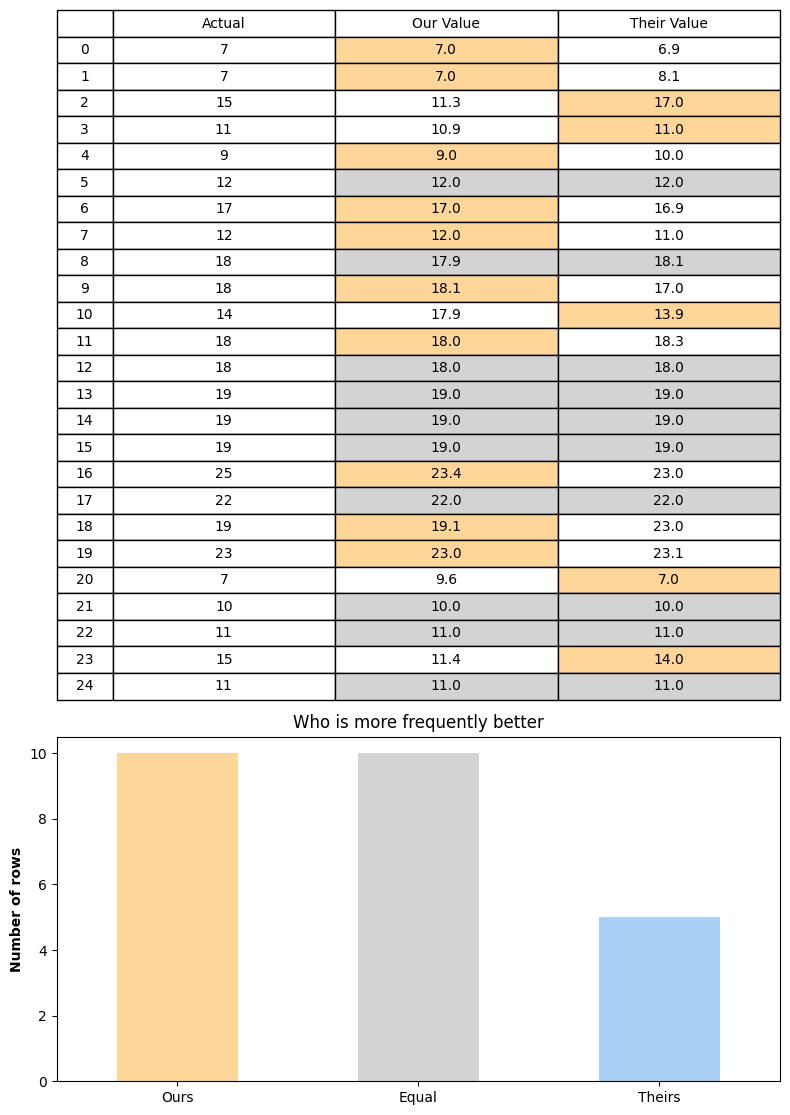

In [99]:
df = pd.read_csv("results_checkpoint.csv")

# best predicted ga values from the literature
best_ga_values = [
    6.9, 8.1, 17.0, 11.0, 10.0,
    12.0, 16.9, 11.0, 18.1, 17.0,
    13.9, 18.3, 18.0, 19.0, 19.0,
    19.0, 23.0, 22.0, 23.0, 23.1,
    7.0, 10.0, 11.0, 14.0, 11.0
]

result_df = compare_with_ga(df, best_ga_values)